# Shareholder-Yield — a quantitative teardown
### The total-yield long-short · the inverted sign · the growth-regime explanation

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Shareholder yield predicts outperformance?: Not supported](https://img.shields.io/badge/Shareholder_yield_predicts_outperformance%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). A theoretically sound factor that runs backwards on the tradable end of the market.

> **Not investment advice.** SEC EDGAR diluted shares + Yahoo annual returns, ~412 current S&P 500 members, 2008-2025. Sources: [`docs/references.md`](../docs/references.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (shareholder_yield/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from shareholder_yield import data, strategy as st
total_yield, fwd, comps = data.fetch_panel()   # cache-first (shared EDGAR pull)
h = st.quantile_hedge(total_yield, fwd, q=0.2, long_high=True)


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| Signal | **Weak** | hedge −2.8%/yr, Sharpe −0.30, t −1.3 — inverted |
| Tradability | **Mirage** | high-yield names trailed low-yield on large caps |
| Shareholder yield predicts outperformance? | **Not supported** | growth beat yield |

> In plain words: a theoretically correct metric, measured in the wrong universe.

## 1 · The claim, steelmanned

- **H1:** high shareholder yield (div yield + net buyback yield) positively predicts next-year cross-sectional returns.
- **H2:** a long-high-yield / short-low-yield hedge is positive and significant.
- **H3:** it's tradable on liquid large caps — not just the micro-cap tail.

## 2 · So what? — what rides on each

H1/H2 would make shareholder yield a superior, free, fundamentals-based signal — pulling from 10-K filings and daily price data. H3 decides whether it works where you can deploy serious capital. A micro-cap-only effect is real science but useless to a large-cap manager.

## 3 · Protocol

EDGAR diluted shares → net buyback yield (YoY share decrease, sign-flipped from net issuance) → annual quintile sort → long top-20% (high yielders), short bottom-20% (low yielders) → next-year hedge, Sharpe, t-stat, hit rate over the XBRL window (2008-2025).

## 4 · The teardown

### 4.1 The long-short, year by year

In [2]:
disp = h.copy()
disp.columns = ['high-yield leg', 'low-yield leg', 'hedge (high-low)']
display((disp * 100).round(1))
s = st.summary(h['hedge'])
print({k: round(v, 3) for k, v in s.items()})

,high-yield leg,low-yield leg,hedge (high-low)
2008,34.7,36.6,-1.9
2009,28.2,25.3,3.0
2010,8.1,-1.3,9.5
2011,24.0,26.5,-2.6
2012,48.2,39.5,8.8
2013,21.1,21.6,-0.5
2014,6.7,12.0,-5.3
2015,20.3,20.8,-0.6
2016,26.5,27.0,-0.6
2017,-6.0,-4.3,-1.7


{'mean': -0.028, 'vol': 0.093, 'sharpe': -0.303, 'tstat': -1.287, 'hit_rate': 0.278, 'max_drawdown': -0.533, 'n': 18}


> In plain words: the hedge mean is **negative** (−2.8%/yr) and wins only 28% of years. **H1 and H2 are rejected on this universe** — the sign is backwards.

### 4.2 Why the sign inverts — H3 fails

Three forces flip it on large caps:

1. **Low yield = growth winners.** 2008-2025's lowest-yield large caps were high-growth tech companies diluting via stock-based compensation — the market leaders who retained cash and drove returns.
2. **The anomaly may live in smaller names.** Boudoukh et al. (2007) test on the full market; Hou-Xue-Zhang (2020) show financing anomalies fade with value-weighting and NYSE breakpoints. The large-cap cohort is likely post-publication and arbitraged.
3. **Survivorship.** Current S&P members exclude distressed high-yielders that delisted — which would have hurt the long leg — yet even this biased test inverts the signal. **H3 rejected.**

### 4.3 Growth vs. yield regime

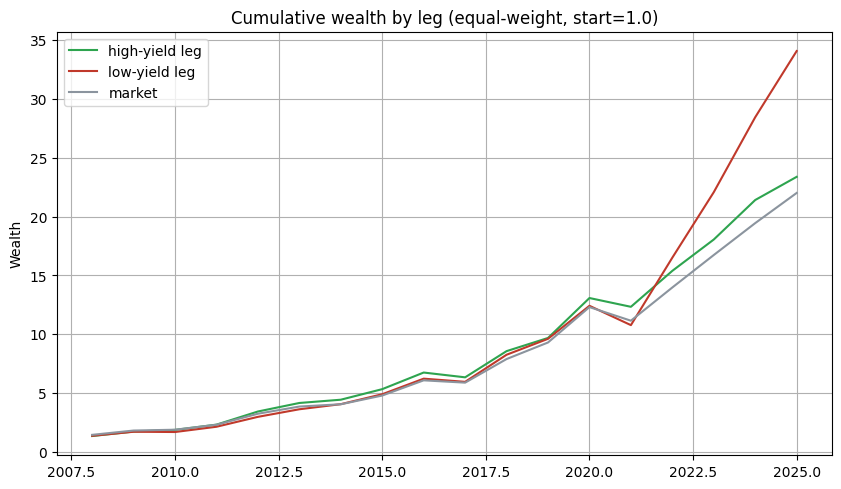

In [3]:
# cumulative wealth of each leg vs market
eq_high = (1 + h['high']).cumprod()
eq_low  = (1 + h['low']).cumprod()
eq_mkt  = (1 + st.market_annual(fwd).reindex(h.index)).cumprod()
pd.DataFrame({'high-yield leg': eq_high, 'low-yield leg': eq_low, 'market': eq_mkt}).plot(
    title='Cumulative wealth by leg (equal-weight, start=1.0)',
    color=['#2ea44f', '#c0392b', '#8b949e']
)
plt.ylabel('Wealth'); plt.show()

## 5 · The verdict

H1/H2/H3 all rejected on tradable large caps → Signal `WEAK` (inverted at −2.8%/yr, t −1.3), Tradability `MIRAGE`, shareholder-yield-predicts-outperformance `NOT SUPPORTED`. The fingerprinted run is in [`docs/results.md`](../docs/results.md).

## 6 · Could you trade it?

Not on this universe. To harvest a genuine premium you'd need: (a) a broader universe including small caps; (b) value-weighting with NYSE breakpoints; (c) delisting-inclusive returns. The large-cap S&P 500 is too well-arbitraged and too dominated by the growth-beats-yield regime to show this factor working.

## 7 · Going further

Forks: (a) Russell 2000 / micro-cap universe; (b) add explicit dividend yield (yfinance); (c) composite with accruals ([52](../../52-smoke-screen/)) and asset growth ([44](../../44-growth-spurt/)) into a quality + capital-discipline factor. The pure buyback predecessor: [64 Share-Shuffle](../../64-share-shuffle/).